# 📊 EDA — LushProtein Customer Insights
**Medallion Architecture | Silver Layer Analysis**

Sections:
1. Revenue & Orders Over Time
2. Customer Segmentation (RFM from Tags)
3. Product Mix & SKU Analysis
4. Subscription vs One-Off Analysis
5. Churn & Retention Analysis
6. Discount Effectiveness
7. Traffic & Acquisition Channels


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import sys

# Double-safe Jupyter detection
is_jupyter = False
try:
    shell = get_ipython().__class__.__name__
    if shell == 'ZMQInteractiveShell':
        is_jupyter = True
except NameError:
    pass
if not is_jupyter and 'ipykernel' in sys.modules:
    is_jupyter = True

if not is_jupyter:
    import matplotlib
    matplotlib.use('Agg')

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

BASE = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
SILVER = os.path.join(BASE, 'medallion', 'silver')

# Override plt.show to automatically save all charts as files ONLY when running programmatically as a script
if not is_jupyter:
    _fig_counter = 1
    def _custom_show(*args, **kwargs):
        global _fig_counter
        out_dir = os.path.join(BASE, 'outputs')
        os.makedirs(out_dir, exist_ok=True)
        save_path = os.path.join(out_dir, f'eda_chart_{_fig_counter}.png')
        plt.savefig(save_path, bbox_inches='tight')
        plt.close()
        print(f'📈 Saved figure to: outputs/eda_chart_{_fig_counter}.png')
        _fig_counter += 1
    plt.show = _custom_show

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5),
                     'axes.titlesize': 13, 'axes.labelsize': 11})

# Load all silver tables
orders       = pd.read_parquet(os.path.join(SILVER, 'silver_orders.parquet'))
lines        = pd.read_parquet(os.path.join(SILVER, 'silver_line_items.parquet'))
products     = pd.read_parquet(os.path.join(SILVER, 'silver_products.parquet'))
discounts    = pd.read_parquet(os.path.join(SILVER, 'silver_discounts.parquet'))
sessions     = pd.read_parquet(os.path.join(SILVER, 'silver_sessions.parquet'))
rc_orders    = pd.read_parquet(os.path.join(SILVER, 'silver_recharge_orders.parquet'))
rc_checkout  = pd.read_parquet(os.path.join(SILVER, 'silver_recharge_order_items.parquet'))
rc_recurring = pd.read_parquet(os.path.join(SILVER, 'silver_recharge_recurring.parquet'))
churned      = pd.read_parquet(os.path.join(SILVER, 'silver_recharge_churned.parquet'))
reactivated  = pd.read_parquet(os.path.join(SILVER, 'silver_recharge_reactivated.parquet'))

# Derive columns to support downstream analyses in this notebook
orders['order_year'] = orders['Processed At'].dt.year
orders['order_month'] = orders['Processed At'].dt.to_period('M').astype(str)
orders['is_cancelled'] = orders['Cancelled At'].notna()
orders['is_subscription'] = orders['Source'].str.strip().eq('subscription_contract')
orders['store'] = orders['Name'].str.extract(r'^#?(LP([A-Z]*))')[0].fillna('LP')
store_map = {'LP': 'SG', 'LPSG': 'SG_Sub', 'LPMY': 'MY', 'LPHK': 'HK'}
orders['store_label'] = orders['store'].map(store_map).fillna('Other')
orders['shopify_customer_id'] = orders['Customer: ID']

lines['order_year'] = pd.to_datetime(lines['Processed At'], errors='coerce').dt.year

churned['churn_year'] = churned['subscription_churn_date'].dt.year
churned['subscription_duration_days'] = (churned['subscription_churn_date'] - churned['subscription_activation_date']).dt.days
reactivated['days_to_reactivate'] = (reactivated['reactivated_date'] - reactivated['first_subscription_activation_date']).dt.days

# Derive columns for discounts
def classify_code(name):
    n = str(name).upper()
    if 'AFFILIATE' in n:  return 'affiliate'
    if any(k in n for k in ['WELCOME','HELLO','HI']):  return 'welcome'
    if any(k in n for k in ['BUNDLE','PAIR','COMBO']):  return 'bundle'
    if any(k in n for k in ['EVENT','FAIR','EXPO']):   return 'event'
    if any(k in n for k in ['SG','MY','HK']):          return 'market_promo'
    return 'other'

discounts['discount_code'] = discounts['Name'].str.strip()
discounts['times_used'] = pd.to_numeric(discounts['Times Used In Total'], errors='coerce').fillna(0).astype(int)
discounts['has_usage'] = discounts['times_used'] > 0
discounts['discount_value'] = pd.to_numeric(discounts['Value'], errors='coerce')
discounts['code_class'] = discounts['discount_code'].apply(classify_code)

# Derive columns for sessions
sessions['visitors'] = pd.to_numeric(sessions['Online store visitors'], errors='coerce')
sessions['sessions'] = pd.to_numeric(sessions['Sessions'], errors='coerce')
sessions['referrer_source']  = sessions['Referrer source'].str.strip()
sessions['referrer_name']    = sessions['Referrer name'].str.strip()
sessions['session_city']     = sessions['Session city'].str.strip()
sessions['utm_campaign']     = sessions['UTM campaign'].str.strip()
sessions['utm_medium']       = sessions['UTM medium'].str.strip()
sessions['utm_source']       = sessions['UTM source'].str.strip()
bronze_sessions = pd.read_parquet(os.path.join(BASE, 'medallion', 'bronze', 'bronze_sessions.parquet'))
sessions['landing_page']     = bronze_sessions['Landing page path'].str.strip().str.lower()
orders['order_id'] = orders['ID']
orders['processed_at'] = orders['Processed At']
print("✅ All silver tables loaded.")
print(f"  orders          : {orders.shape}")
print(f"  line_items      : {lines.shape}")
print(f"  products        : {products.shape}")
print(f"  discounts       : {discounts.shape}")
print(f"  sessions        : {sessions.shape}")
print(f"  rc_orders       : {rc_orders.shape}")
print(f"  rc_checkout     : {rc_checkout.shape}")
print(f"  rc_recurring    : {rc_recurring.shape}")
print(f"  churned         : {churned.shape}")
print(f"  reactivated     : {reactivated.shape}")


✅ All silver tables loaded.
  orders          : (102461, 67)
  line_items      : (51220, 28)
  products        : (56, 6)
  discounts       : (366, 11)
  sessions        : (137033, 18)
  rc_orders       : (1215, 9)
  rc_checkout     : (1094, 15)
  rc_recurring    : (650, 15)
  churned         : (526, 16)
  reactivated     : (50, 6)


## 1. Revenue & Orders Over Time

In [2]:
# Filter to paid, non-cancelled orders
paid = orders[
    (orders['Payment: Status'] == 'paid') &
    (~orders['is_cancelled'])
].copy()

print(f"Paid non-cancelled orders: {len(paid):,}")
print(paid[['Price: Total', 'order_year']].describe())


Paid non-cancelled orders: 99,662
       Price: Total    order_year
count  27256.000000  99662.000000
mean     109.219984   2022.783679
std      407.829339      1.887148
min        0.000000   2019.000000
25%       27.900000   2021.000000
50%       56.760000   2022.000000
75%      102.000000   2025.000000
max    33415.200000   2026.000000


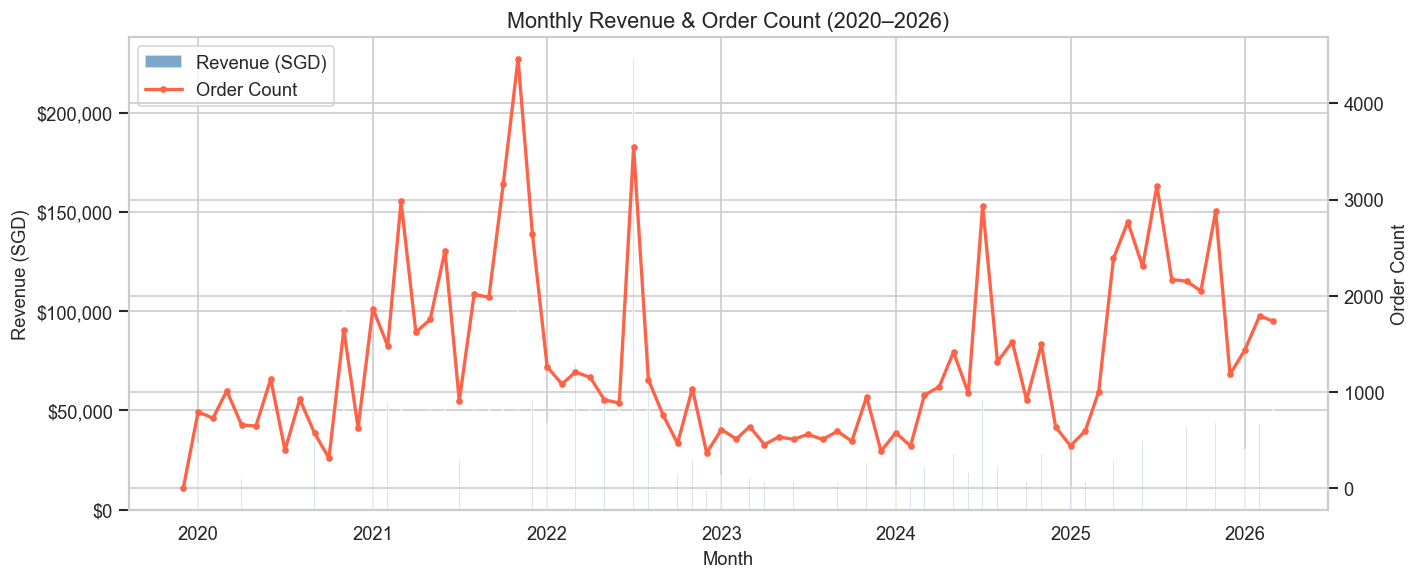

In [3]:
# Monthly revenue trend
paid['order_month_dt'] = pd.to_datetime(paid['order_month'], format='%Y-%m', errors='coerce')
monthly = (paid.groupby('order_month_dt')
               .agg(revenue=('Price: Total', 'sum'), orders=('order_id', 'count'))
               .reset_index().sort_values('order_month_dt'))

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.bar(monthly['order_month_dt'], monthly['revenue'], color='steelblue', alpha=0.7, label='Revenue (SGD)')
ax2.plot(monthly['order_month_dt'], monthly['orders'], color='tomato', lw=2, marker='o', ms=3, label='Order Count')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (SGD)')
ax2.set_ylabel('Order Count')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_title('Monthly Revenue & Order Count (2020–2026)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()


In [4]:
# Annual revenue summary
annual = (paid.groupby('order_year')
              .agg(revenue=('Price: Total','sum'),
                   orders=('order_id','count'),
                   aov=('Price: Total','mean'),
                   unique_customers=('shopify_customer_id','nunique'))
              .reset_index())
annual['revenue_growth_%'] = annual['revenue'].pct_change() * 100
print("Annual Revenue Summary:")
display(annual.style.format({'revenue':'${:,.0f}', 'aov':'${:.2f}',
                              'revenue_growth_%':'{:.1f}%'}).bar(subset=['revenue'], color='#90c8f0'))


Annual Revenue Summary:


,order_year,revenue,orders,aov,unique_customers,revenue_growth_%
0,2019,$29,2,$28.90,1,nan%
1,2020,"$450,730",9450,$158.32,1697,1559521.0%
2,2021,"$832,794",27356,$133.12,3812,84.8%
3,2022,"$734,969",13808,$197.68,2300,-11.7%
4,2023,"$175,081",6740,$78.87,1388,-76.2%
5,2024,"$273,303",14258,$65.82,2586,56.1%
6,2025,"$369,220",23083,$57.29,4074,35.1%
7,2026,"$140,773",4965,$87.06,1235,-61.9%


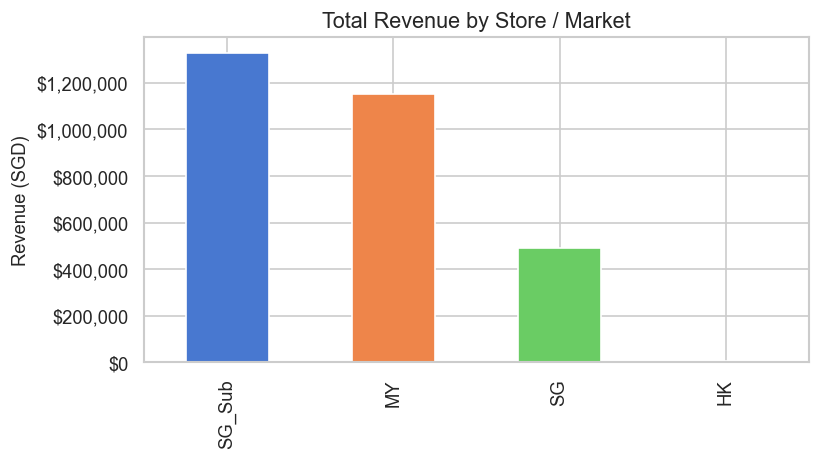

In [5]:
# Revenue by store/market
store_rev = paid.groupby('store_label')['Price: Total'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,4))
store_rev.plot(kind='bar', ax=ax, color=sns.color_palette('muted', len(store_rev)))
ax.set_title('Total Revenue by Store / Market')
ax.set_ylabel('Revenue (SGD)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlabel('')
plt.tight_layout()
plt.show()


## 2. Customer Segmentation via RFM Tags

In [6]:
# Extract RFM group from Customer: Tags
tags_df = paid[['shopify_customer_id', 'Customer: Tags', 'order_year']].drop_duplicates(subset='shopify_customer_id')

def extract_tag(tags, prefix):
    if pd.isna(tags): return None
    for t in str(tags).split(','):
        t = t.strip()
        if t.startswith(prefix):
            return t.replace(prefix, '').strip()
    return None

tags_df['rfm_group']   = tags_df['Customer: Tags'].apply(lambda x: extract_tag(x, 'RFM Group '))
tags_df['rfm_score']   = tags_df['Customer: Tags'].apply(lambda x: extract_tag(x, 'RFM Score '))
tags_df['gender']      = tags_df['Customer: Tags'].apply(
    lambda x: 'male' if 'male' in str(x).lower() and 'female' not in str(x).lower()
              else ('female' if 'female' in str(x).lower() else None))
tags_df['is_active_sub'] = tags_df['Customer: Tags'].apply(
    lambda x: 'Active Subscriber' in str(x) if pd.notna(x) else False)

print("RFM Group distribution:")
print(tags_df['rfm_group'].value_counts())


RFM Group distribution:
rfm_group
Ex lover             3214
Breakup              2878
About to dump you    1146
Don Juan              671
Platonic friend       509
Potential lover       270
Apprentice            269
Lover                 189
_no_rfm               112
Soulmate               86
Flirting               63
New passion            60
Name: count, dtype: int64


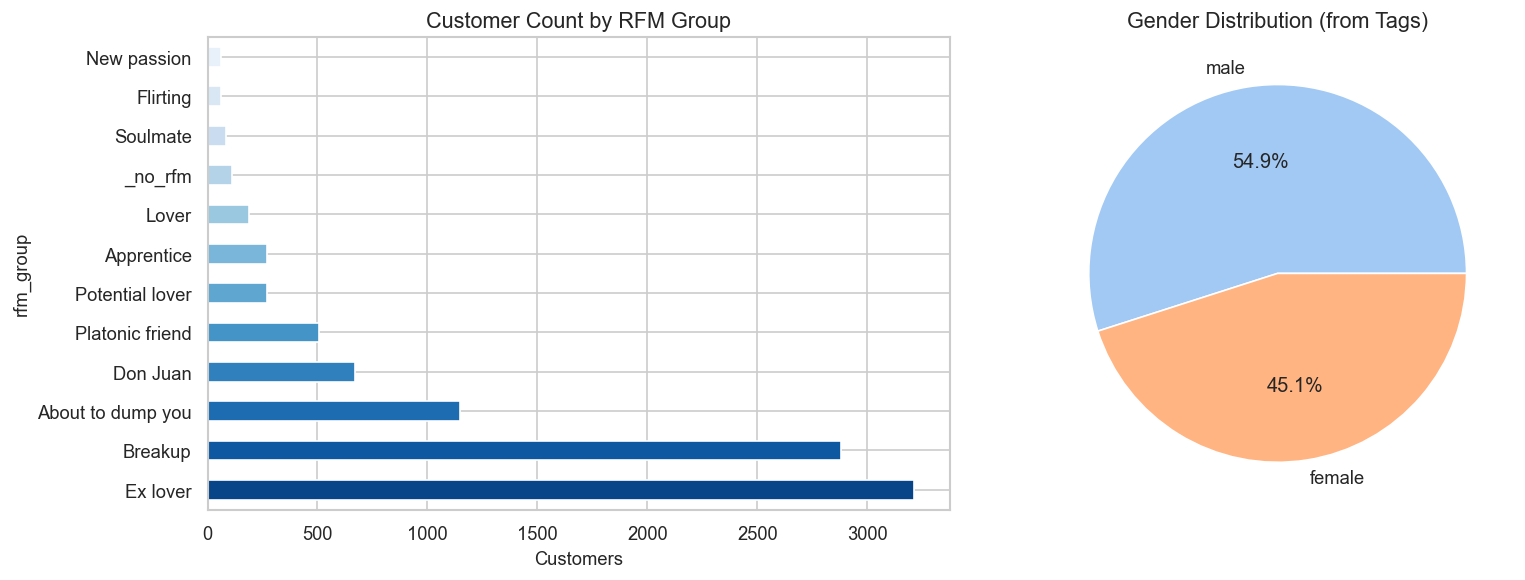

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RFM Group
rfm_counts = tags_df['rfm_group'].value_counts().dropna()
rfm_counts.plot(kind='barh', ax=axes[0], color=sns.color_palette('Blues_r', len(rfm_counts)))
axes[0].set_title('Customer Count by RFM Group')
axes[0].set_xlabel('Customers')

# Gender
gender_counts = tags_df['gender'].value_counts().dropna()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel', len(gender_counts)))
axes[1].set_title('Gender Distribution (from Tags)')

plt.tight_layout()
plt.show()


In [8]:
# Active vs Inactive subscribers
sub_status = tags_df['is_active_sub'].value_counts()
print("Active Subscriber flag distribution:")
print(sub_status.rename({True: 'Active Subscriber', False: 'Not / Inactive'}))

# Email marketing consent
email_mkt = paid['Customer: Email Marketing Status'].value_counts()
print("\nEmail Marketing Status:")
print(email_mkt)


Active Subscriber flag distribution:
is_active_sub
Not / Inactive       13510
Active Subscriber      209
Name: count, dtype: int64

Email Marketing Status:
Customer: Email Marketing Status
subscribed        64652
unsubscribed      16587
not_subscribed    11232
invalid               4
Name: count, dtype: int64


## 3. Product Mix & Top SKUs

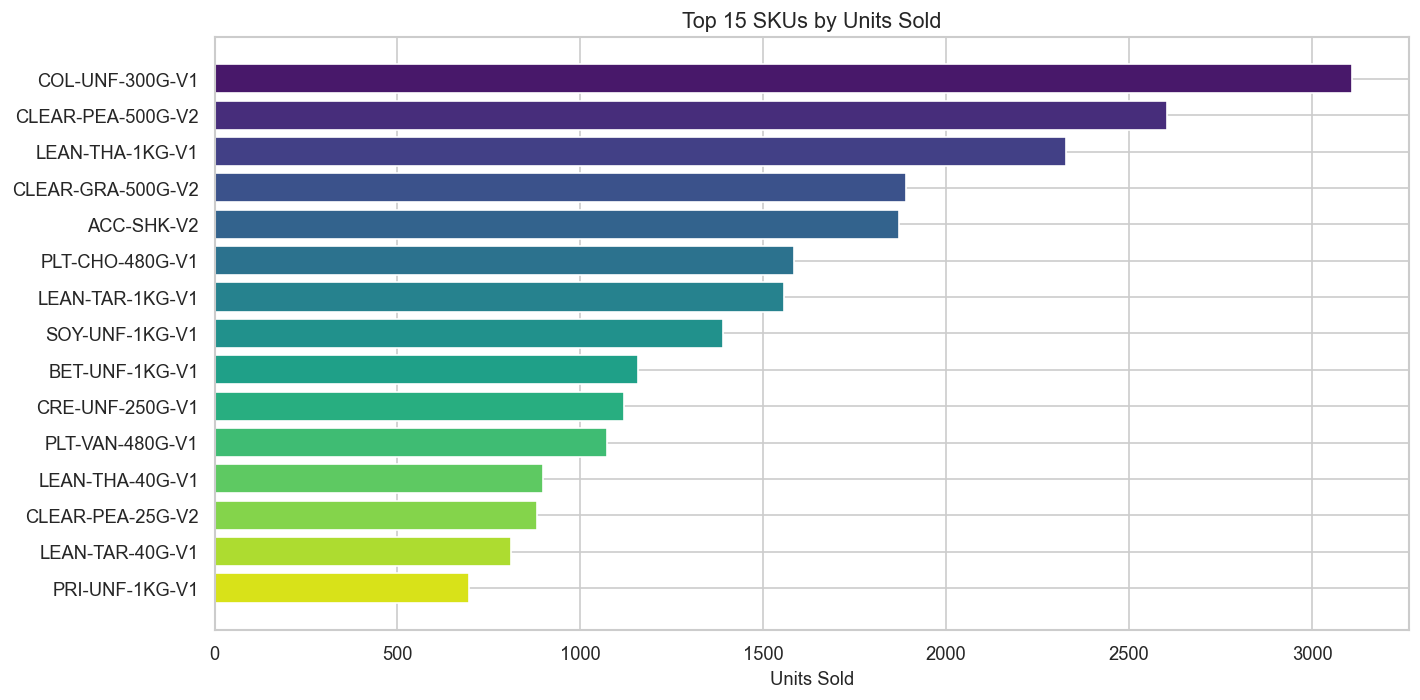

,Line: Variant SKU,units,revenue,orders
0,COL-UNF-300G-V1,"3,109","$104,024.45","1,797"
1,CLEAR-PEA-500G-V2,"2,603","$158,726.81","1,919"
2,LEAN-THA-1KG-V1,"2,327","$121,720.51","1,794"
3,CLEAR-GRA-500G-V2,"1,889","$112,663.04","1,520"
4,ACC-SHK-V2,"1,870","$17,938.88","1,541"
5,PLT-CHO-480G-V1,"1,584","$43,039.79",741
6,LEAN-TAR-1KG-V1,"1,557","$83,271.15","1,015"
7,SOY-UNF-1KG-V1,"1,389","$43,148.45",936
8,BET-UNF-1KG-V1,"1,158","$56,870.87",709
9,CRE-UNF-250G-V1,"1,120","$27,010.68",824


In [9]:
# Top 15 SKUs by units sold
top_skus = (lines.groupby('Line: Variant SKU')
                 .agg(units=('Line: Quantity','sum'),
                      revenue=('Line: Total','sum'),
                      orders=('order_id','nunique'))
                 .sort_values('units', ascending=False)
                 .head(15).reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_skus['Line: Variant SKU'], top_skus['units'],
               color=sns.color_palette('viridis', len(top_skus)))
ax.set_xlabel('Units Sold')
ax.set_title('Top 15 SKUs by Units Sold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(top_skus.style.format({'units':'{:,.0f}', 'revenue':'${:,.2f}', 'orders':'{:,}'}))


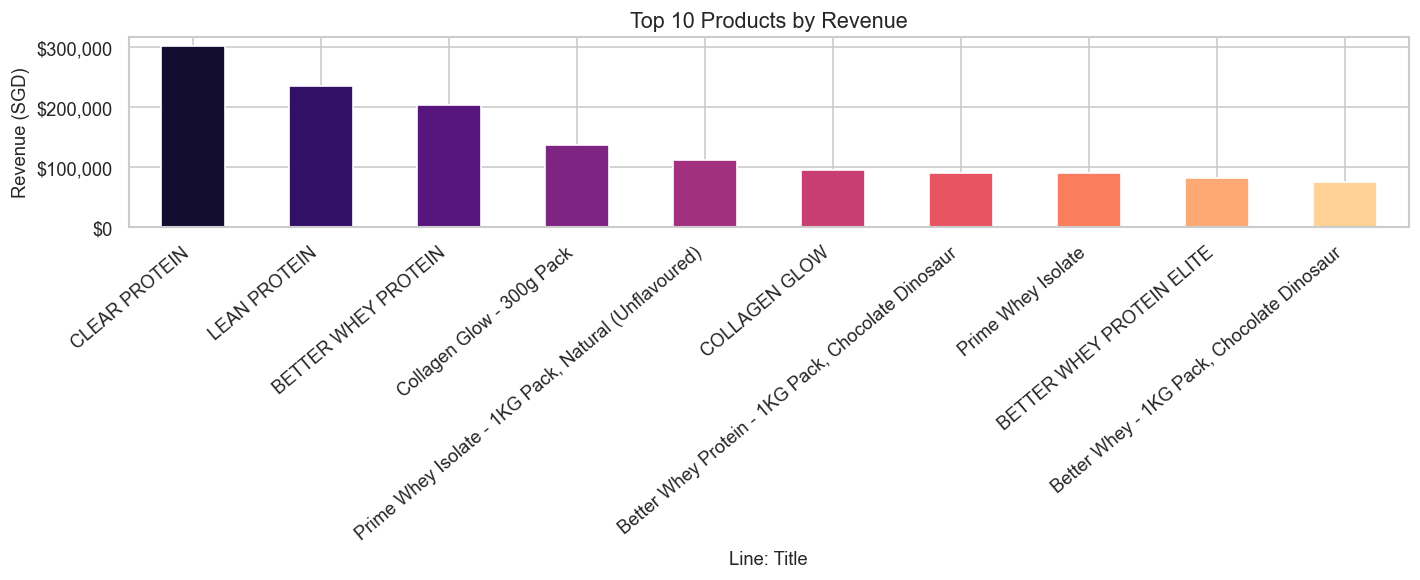

In [10]:
# Revenue by product title (top 10)
top_products = (lines.groupby('Line: Title')
                     .agg(revenue=('Line: Total','sum'))
                     .sort_values('revenue', ascending=False)
                     .head(10))

fig, ax = plt.subplots(figsize=(12, 5))
top_products['revenue'].plot(kind='bar', ax=ax, color=sns.color_palette('magma', 10))
ax.set_title('Top 10 Products by Revenue')
ax.set_ylabel('Revenue (SGD)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
plt.tight_layout()
plt.show()


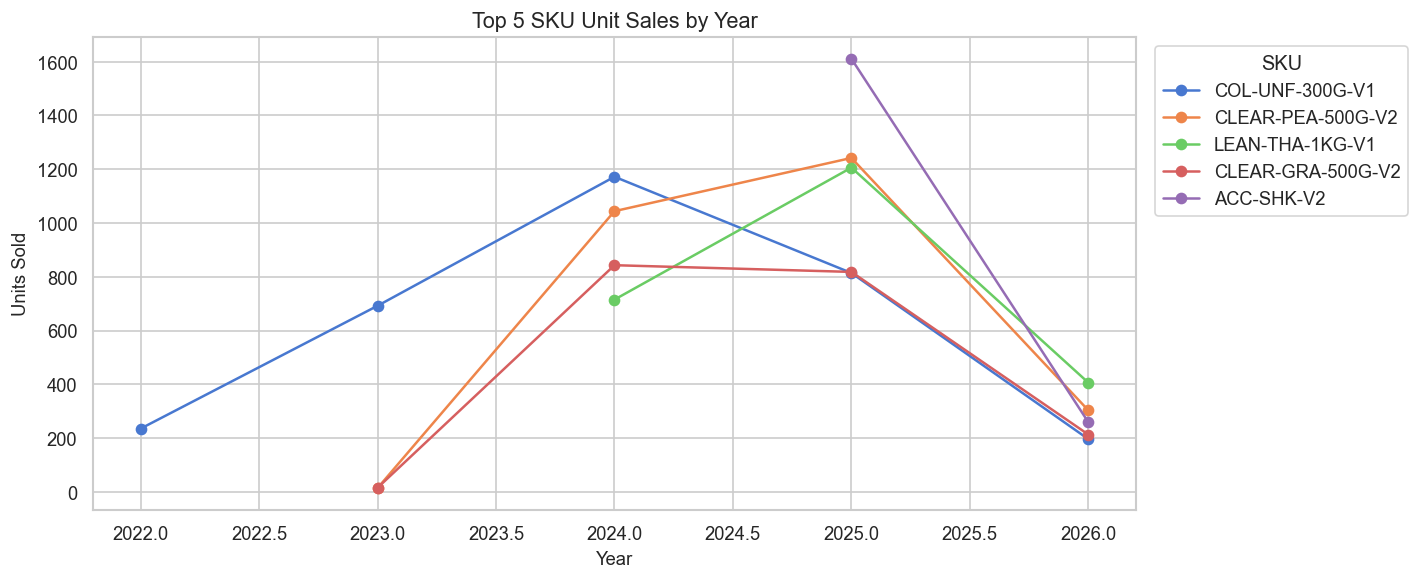

In [11]:
# Units sold trend by year for top 5 SKUs
top5_skus = top_skus['Line: Variant SKU'].head(5).tolist()
sku_trend = (lines[lines['Line: Variant SKU'].isin(top5_skus)]
             .groupby(['order_year', 'Line: Variant SKU'])['Line: Quantity']
             .sum().reset_index())

fig, ax = plt.subplots(figsize=(12, 5))
for sku in top5_skus:
    d = sku_trend[sku_trend['Line: Variant SKU'] == sku]
    ax.plot(d['order_year'], d['Line: Quantity'], marker='o', label=sku)
ax.set_title('Top 5 SKU Unit Sales by Year')
ax.set_ylabel('Units Sold')
ax.set_xlabel('Year')
ax.legend(title='SKU', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()


## 4. Subscription vs One-Off Orders

Subscription vs One-Off summary:


,orders,revenue,unique_customers
is_subscription,,,
One-Off,96163,"$2,891,759",13716
Subscription,3499,"$85,141",481


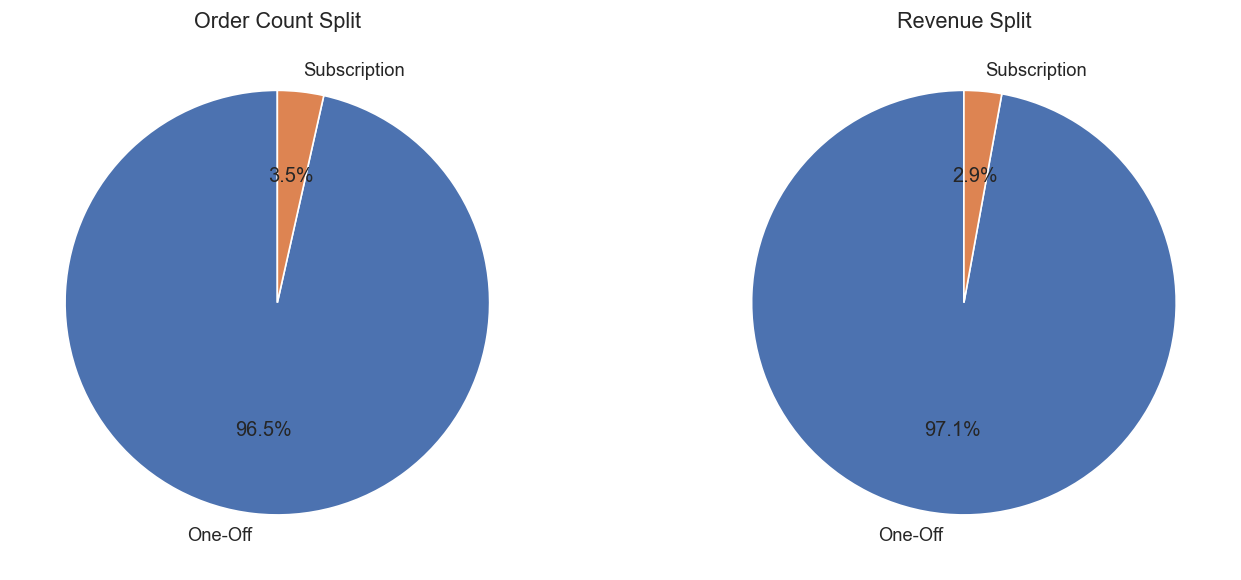

In [12]:
sub_split = paid.groupby('is_subscription').agg(
    orders=('order_id','count'),
    revenue=('Price: Total','sum'),
    unique_customers=('shopify_customer_id','nunique')
).rename(index={True:'Subscription', False:'One-Off'})

print("Subscription vs One-Off summary:")
display(sub_split.style.format({'revenue':'${:,.0f}'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sub_split['orders'].plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
                         colors=['#4C72B0','#DD8452'], startangle=90)
axes[0].set_title('Order Count Split')
axes[0].set_ylabel('')

sub_split['revenue'].plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                          colors=['#4C72B0','#DD8452'], startangle=90)
axes[1].set_title('Revenue Split')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()


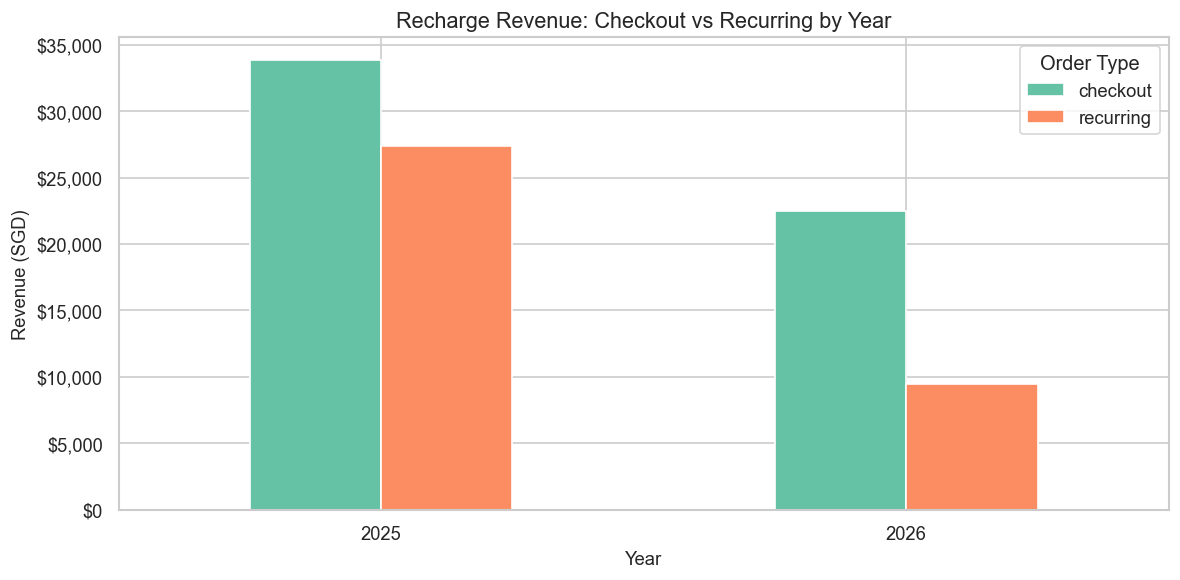

In [13]:
# Recharge: checkout vs recurring revenue over time
rc_orders['order_year'] = rc_orders['metric_date'].dt.year
rc_annual = rc_orders.groupby(['order_year','order_type'])['order_total'].sum().unstack(fill_value=0)
rc_annual.plot(kind='bar', figsize=(10,5), color=sns.color_palette('Set2',2))
plt.title('Recharge Revenue: Checkout vs Recurring by Year')
plt.ylabel('Revenue (SGD)')
plt.xlabel('Year')
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend(title='Order Type')
plt.tight_layout()
plt.show()


## 5. Churn & Retention Analysis

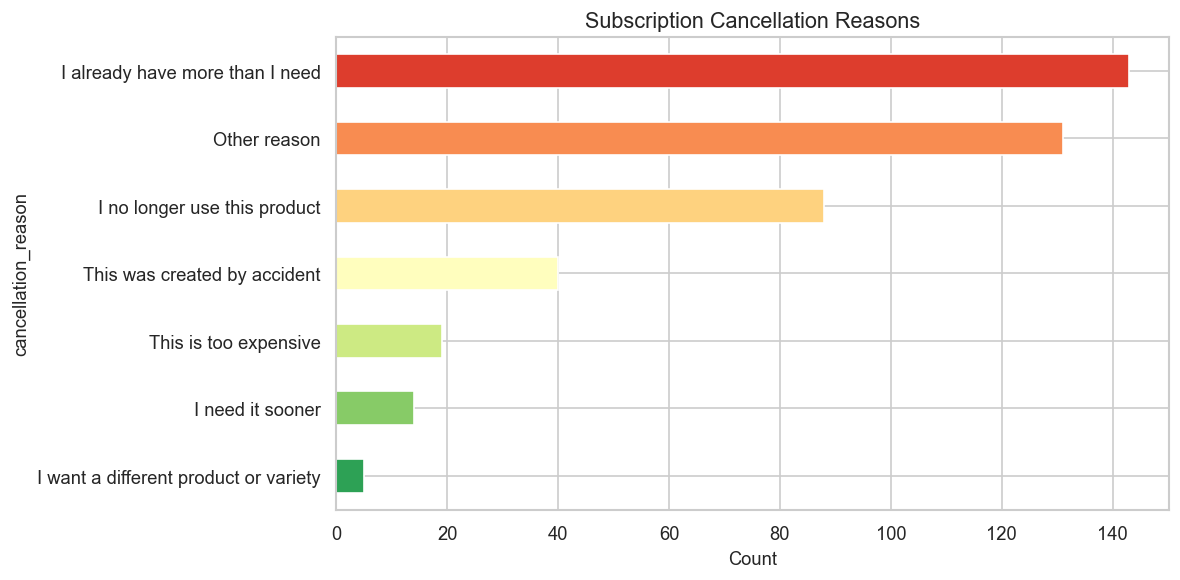

cancellation_reason
I already have more than I need          143
Other reason                             131
I no longer use this product              88
This was created by accident              40
This is too expensive                     19
I need it sooner                          14
I want a different product or variety      5
Name: count, dtype: int64


In [14]:
# Cancellation reasons
reason_counts = churned['cancellation_reason'].value_counts().dropna()
fig, ax = plt.subplots(figsize=(10, 5))
reason_counts.sort_values().plot(kind='barh', ax=ax,
    color=sns.color_palette('RdYlGn_r', len(reason_counts)))
ax.set_title('Subscription Cancellation Reasons')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()
print(reason_counts)


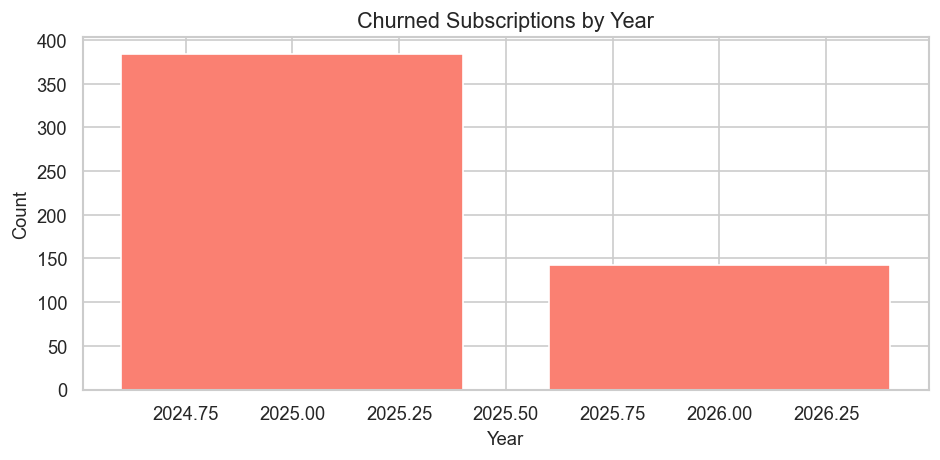

In [15]:
# Churn by year
churn_yr = churned.groupby('churn_year').size().reset_index(name='churns')
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(churn_yr['churn_year'], churn_yr['churns'], color='salmon')
ax.set_title('Churned Subscriptions by Year')
ax.set_ylabel('Count')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()


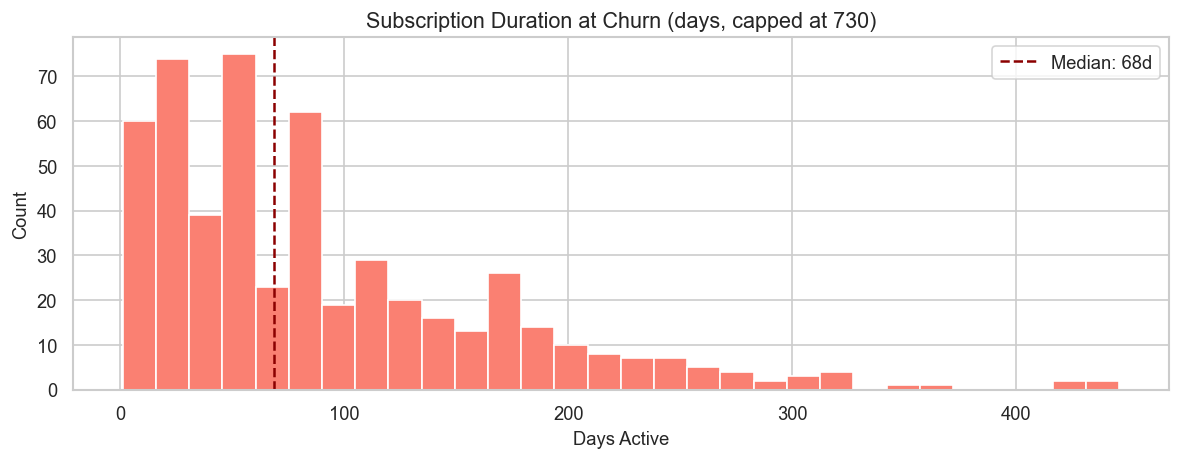

Median subscription duration at churn: 68 days
count    526.000000
mean      91.408745
std       79.427704
min        1.000000
25%       29.250000
50%       68.500000
75%      127.000000
max      446.000000
Name: subscription_duration_days, dtype: float64


In [16]:
# Subscription duration at churn
fig, ax = plt.subplots(figsize=(10, 4))
churned['subscription_duration_days'].dropna().clip(upper=730).hist(
    bins=30, ax=ax, color='salmon', edgecolor='white')
ax.set_title('Subscription Duration at Churn (days, capped at 730)')
ax.set_xlabel('Days Active')
ax.set_ylabel('Count')
median_days = churned['subscription_duration_days'].median()
ax.axvline(median_days, color='darkred', linestyle='--', label=f'Median: {median_days:.0f}d')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Median subscription duration at churn: {median_days:.0f} days")
print(churned['subscription_duration_days'].describe())


Total reactivated subscribers: 50
Median days to reactivate: 112


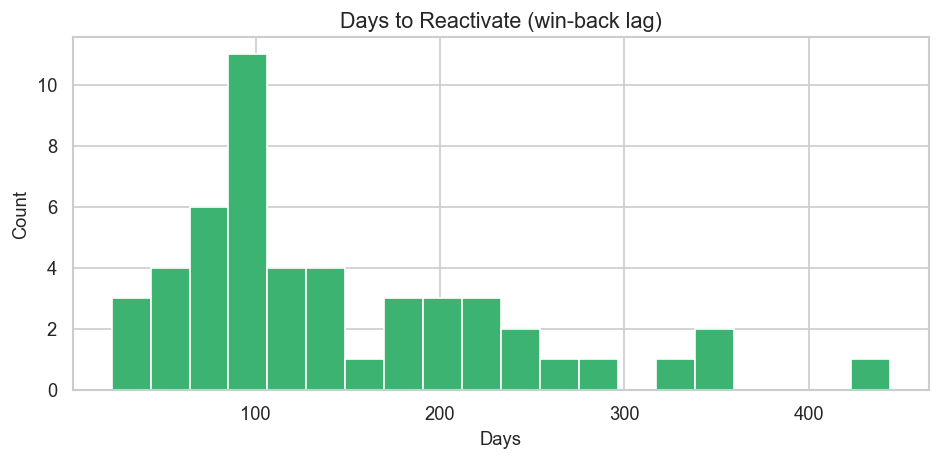

In [17]:
# Reactivated subscribers
print(f"Total reactivated subscribers: {len(reactivated)}")
print(f"Median days to reactivate: {reactivated['days_to_reactivate'].median():.0f}")
fig, ax = plt.subplots(figsize=(8, 4))
reactivated['days_to_reactivate'].clip(upper=1000).hist(
    bins=20, ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('Days to Reactivate (win-back lag)')
ax.set_xlabel('Days')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


## 6. Discount Effectiveness

Discount codes with usage: 163 / 366


,codes,total_uses,avg_value
code_class,,,
other,136,"1,922",43.7
welcome,7,523,40.0
market_promo,12,197,47.9
affiliate,7,138,50.1
event,1,1,100.0


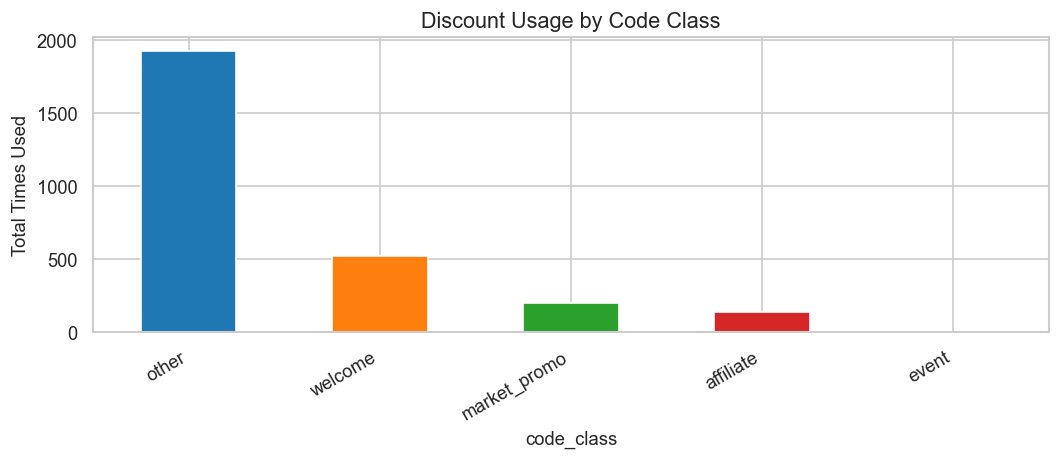

In [18]:
active_disc = discounts[discounts['has_usage']].copy()
print(f"Discount codes with usage: {len(active_disc)} / {len(discounts)}")

# Usage by code class
by_class = active_disc.groupby('code_class').agg(
    codes=('discount_code','count'),
    total_uses=('times_used','sum'),
    avg_value=('discount_value','mean')
).sort_values('total_uses', ascending=False)

display(by_class.style.format({'avg_value':'{:.1f}', 'total_uses':'{:,}'}))

fig, ax = plt.subplots(figsize=(9, 4))
by_class['total_uses'].plot(kind='bar', ax=ax, color=sns.color_palette('tab10', len(by_class)))
ax.set_title('Discount Usage by Code Class')
ax.set_ylabel('Total Times Used')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()


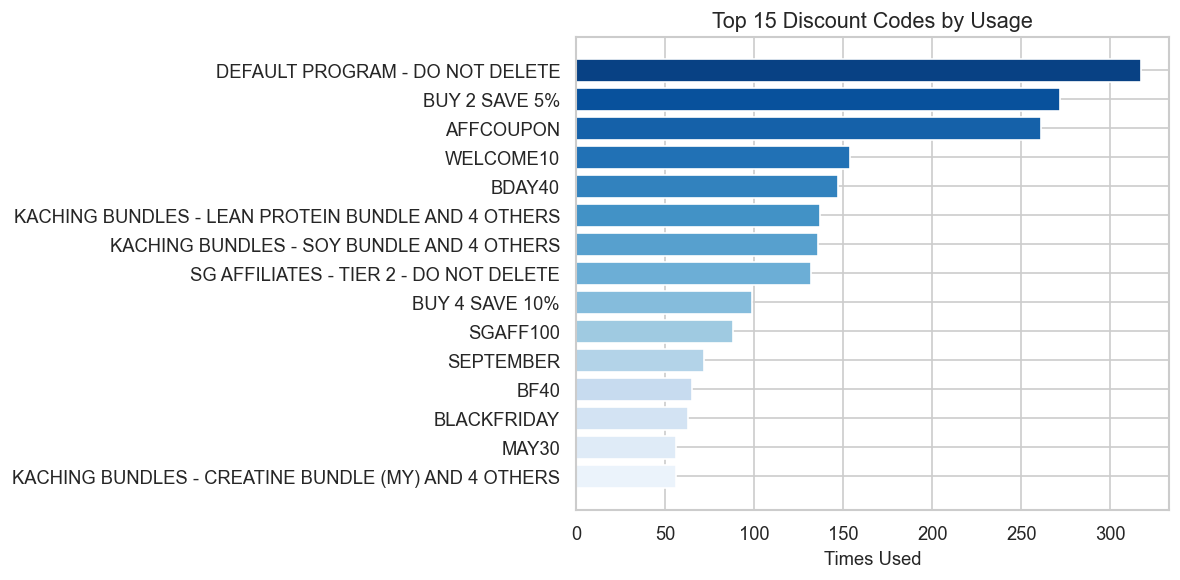

In [19]:
# Top 15 most-used codes
top_codes = active_disc.sort_values('times_used', ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_codes['discount_code'], top_codes['times_used'],
        color=sns.color_palette('Blues_r', 15))
ax.set_title('Top 15 Discount Codes by Usage')
ax.set_xlabel('Times Used')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Orders with discount: 9,031 (9.1% of paid orders)
count    903100.00%
mean           inf%
std            nan%
min           0.01%
25%          17.62%
50%          33.57%
75%          66.68%
max            inf%
Name: disc_rate, dtype: object


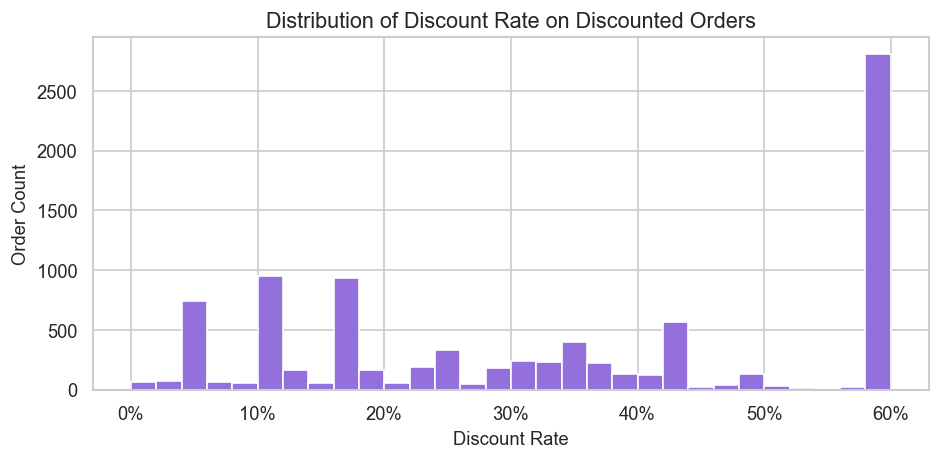

In [20]:
# Order-level discount rate
disc_orders = paid[paid['Price: Total Discount'].notna() &
                   (paid['Price: Total Discount'] > 0)].copy()
disc_orders['disc_rate'] = disc_orders['Price: Total Discount'] / disc_orders['Price: Subtotal']
print(f"Orders with discount: {len(disc_orders):,} ({len(disc_orders)/len(paid):.1%} of paid orders)")
print(disc_orders['disc_rate'].describe().apply(lambda x: f"{x:.2%}"))

fig, ax = plt.subplots(figsize=(8, 4))
disc_orders['disc_rate'].clip(upper=0.6).hist(bins=30, ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('Distribution of Discount Rate on Discounted Orders')
ax.set_xlabel('Discount Rate')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_ylabel('Order Count')
plt.tight_layout()
plt.show()


## 7. Traffic & Acquisition Channels

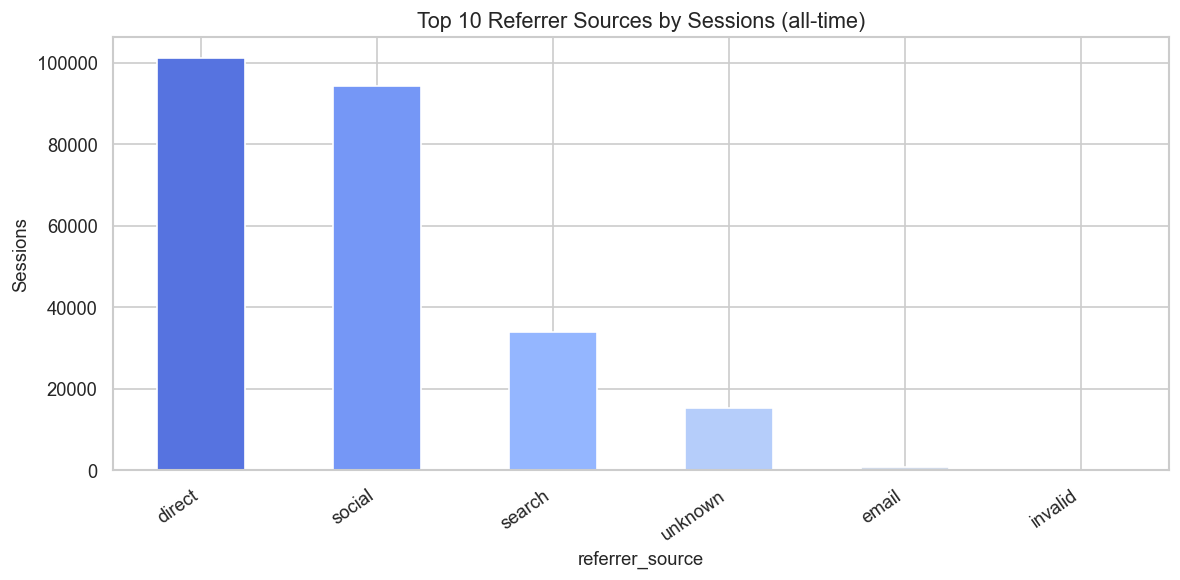

In [21]:
# Top referrer sources by sessions
top_ref = (sessions.groupby('referrer_source')['sessions']
                   .sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(10, 5))
top_ref.plot(kind='bar', ax=ax, color=sns.color_palette('coolwarm', 10))
ax.set_title('Top 10 Referrer Sources by Sessions (all-time)')
ax.set_ylabel('Sessions')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()


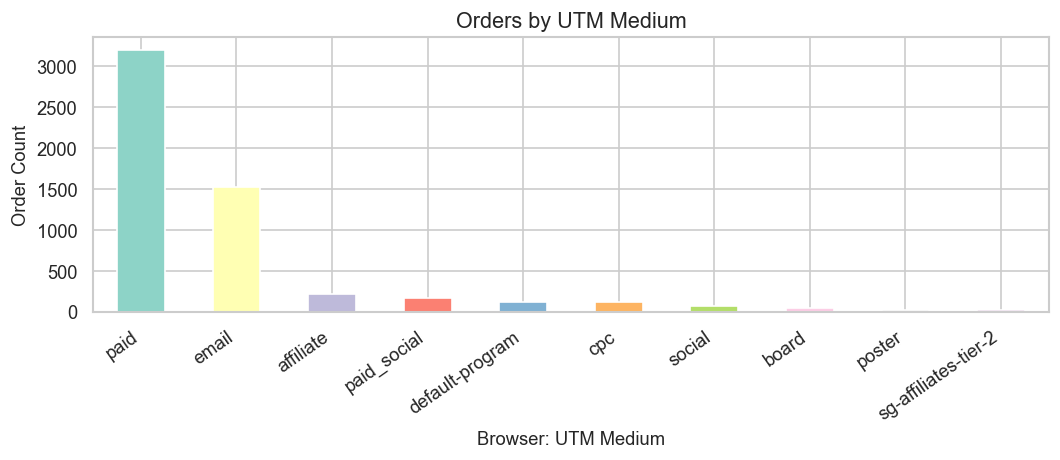

In [22]:
# UTM medium breakdown from order data
utm_med = paid['Browser: UTM Medium'].str.strip().value_counts().head(10)
fig, ax = plt.subplots(figsize=(9, 4))
utm_med.plot(kind='bar', ax=ax, color=sns.color_palette('Set3', len(utm_med)))
ax.set_title('Orders by UTM Medium')
ax.set_ylabel('Order Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()


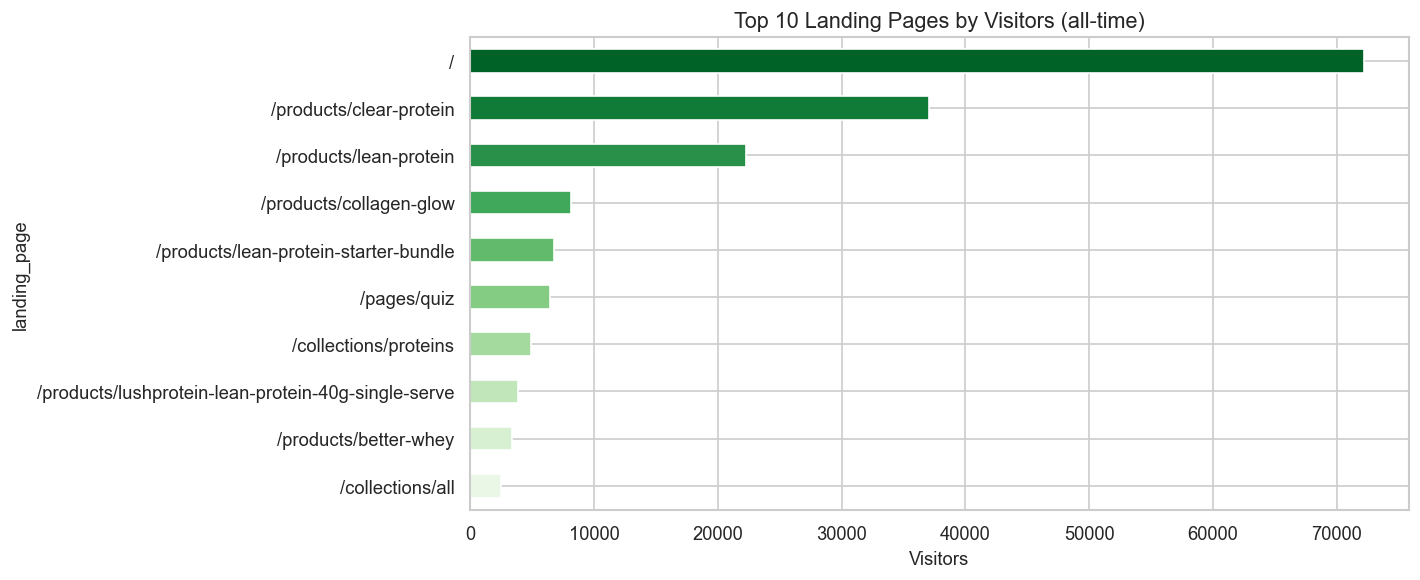

In [23]:
# Top landing pages by visitors
top_landing = (sessions.groupby('landing_page')['visitors']
                       .sum().sort_values(ascending=False).head(10))
fig, ax = plt.subplots(figsize=(12, 5))
top_landing.plot(kind='barh', ax=ax, color=sns.color_palette('Greens_r', 10))
ax.set_title('Top 10 Landing Pages by Visitors (all-time)')
ax.set_xlabel('Visitors')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


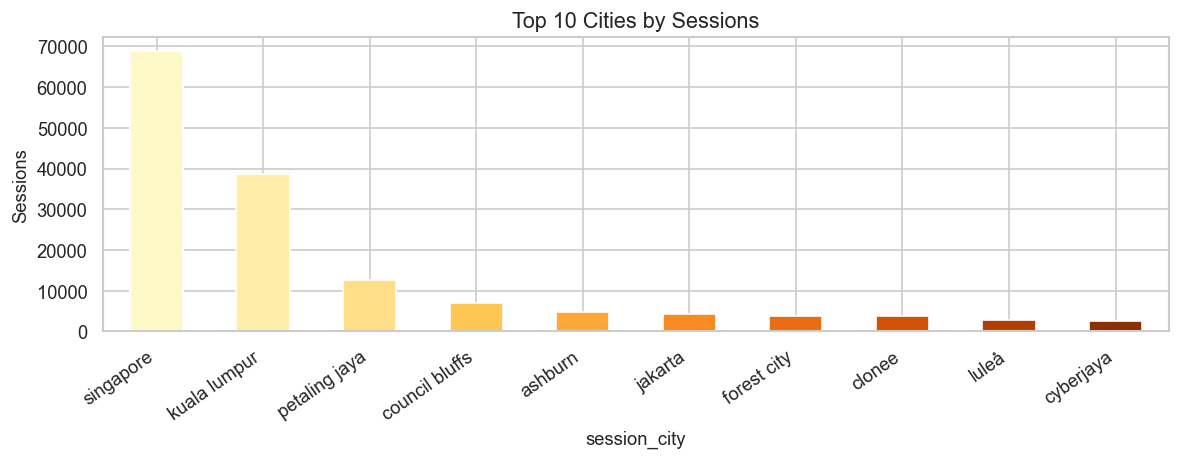

In [24]:
# Top cities by sessions
top_cities = (sessions.groupby('session_city')['sessions']
                      .sum().sort_values(ascending=False).head(10))
fig, ax = plt.subplots(figsize=(10, 4))
top_cities.plot(kind='bar', ax=ax, color=sns.color_palette('YlOrBr', 10))
ax.set_title('Top 10 Cities by Sessions')
ax.set_ylabel('Sessions')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()


## 8. Customer-Level Summary & Lifetime Value

In [25]:
# Build customer-level aggregation from orders
cust = (paid.groupby('shopify_customer_id')
            .agg(
                total_orders  = ('order_id',    'count'),
                total_revenue = ('Price: Total', 'sum'),
                first_order   = ('processed_at', 'min'),
                last_order    = ('processed_at', 'max'),
                store         = ('store_label',  lambda x: x.mode()[0] if len(x) else None),
            )
            .reset_index())

cust['aov']           = cust['total_revenue'] / cust['total_orders']
cust['tenure_days']   = (cust['last_order'] - cust['first_order']).dt.days
cust['is_repeat']     = cust['total_orders'] > 1

print(f"Unique customers: {len(cust):,}")
print(f"Repeat customers: {cust['is_repeat'].sum():,} ({cust['is_repeat'].mean():.1%})")
print("\nCustomer LTV summary:")
display(cust[['total_orders','total_revenue','aov','tenure_days']].describe()
        .style.format('{:.2f}'))


Unique customers: 13,718
Repeat customers: 13,707 (99.9%)

Customer LTV summary:


,total_orders,total_revenue,aov,tenure_days
count,13718.00,13718.00,13718.00,13718.00
mean,7.23,216.28,27.79,116.77
std,17.93,937.04,158.34,312.96
min,1.00,0.00,0.00,0.00
25%,2.00,27.07,7.97,0.00
50%,4.00,61.71,15.86,0.00
75%,8.00,138.00,27.33,28.00
max,1776.00,44382.70,16707.60,2255.00


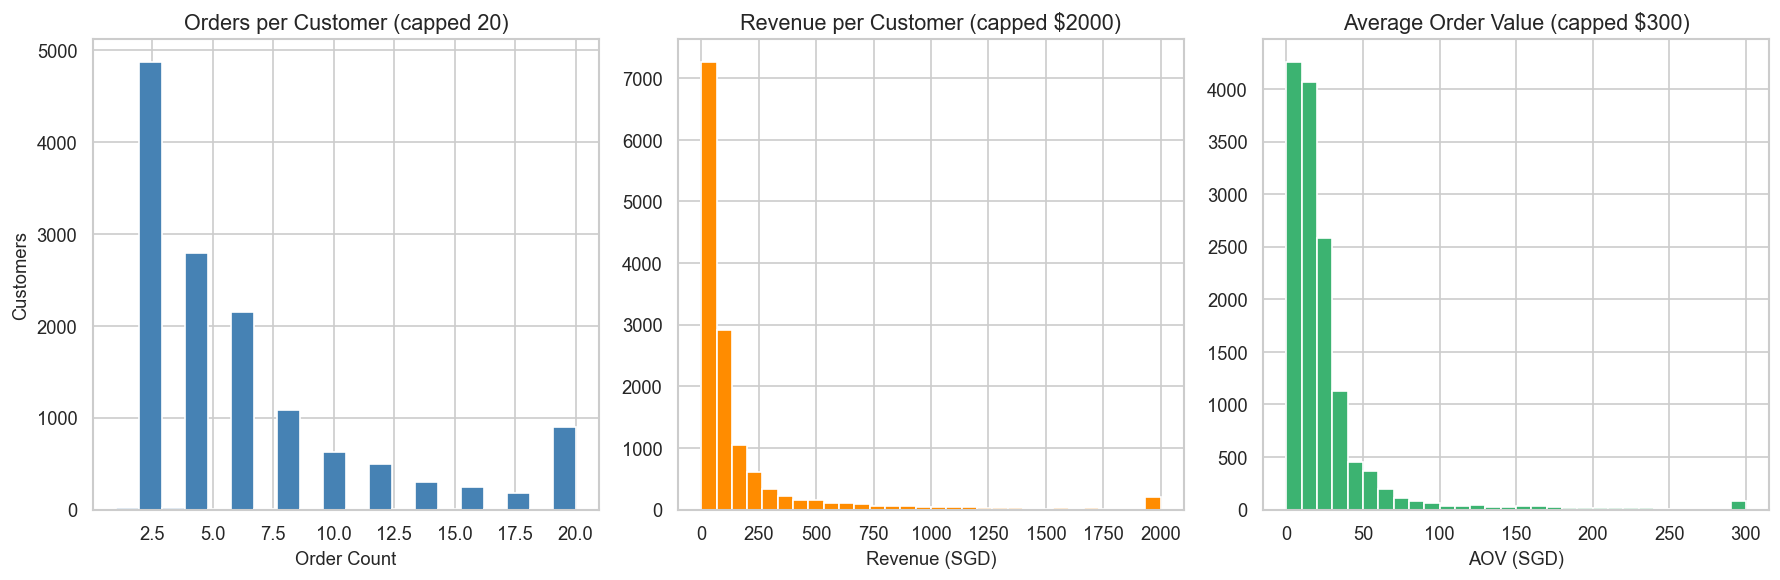

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Orders per customer
cust['total_orders'].clip(upper=20).hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Orders per Customer (capped 20)')
axes[0].set_xlabel('Order Count')
axes[0].set_ylabel('Customers')

# Revenue per customer
cust['total_revenue'].clip(upper=2000).hist(bins=30, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Revenue per Customer (capped $2000)')
axes[1].set_xlabel('Revenue (SGD)')

# AOV
cust['aov'].clip(upper=300).hist(bins=30, ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Average Order Value (capped $300)')
axes[2].set_xlabel('AOV (SGD)')

plt.tight_layout()
plt.show()


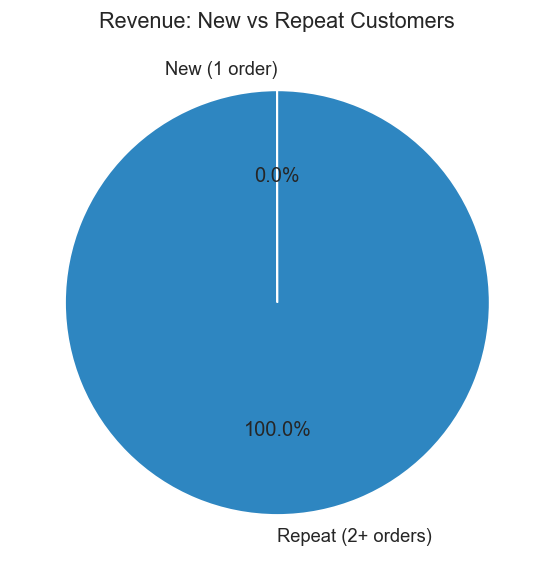

In [27]:
# New vs Repeat revenue split
rev_split = cust.groupby('is_repeat')['total_revenue'].sum()
rev_split.index = ['New (1 order)', 'Repeat (2+ orders)']
fig, ax = plt.subplots(figsize=(6, 5))
rev_split.plot(kind='pie', ax=ax, autopct='%1.1f%%',
               colors=['#AED6F1','#2E86C1'], startangle=90)
ax.set_title('Revenue: New vs Repeat Customers')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


In [28]:
# Cohort retention — first-order year cohorts
cust['cohort_year'] = cust['first_order'].dt.year
cohort_rev = (paid.merge(cust[['shopify_customer_id','cohort_year']], on='shopify_customer_id')
              .groupby(['cohort_year','order_year'])['Price: Total']
              .sum().unstack(fill_value=0))

print("Revenue by Cohort Year × Order Year:")
display(cohort_rev.style.format('${:,.0f}').background_gradient(cmap='Blues', axis=1))


Revenue by Cohort Year × Order Year:


order_year,2019,2020,2021,2022,2023,2024,2025,2026
cohort_year,,,,,,,,
2019,$29,$0,$0,$0,$0,$0,$0,$0
2020,$0,"$450,730","$291,735","$199,250","$35,014","$36,370","$16,434","$3,581"
2021,$0,$0,"$541,059","$211,541","$27,852","$26,098","$10,583","$2,712"
2022,$0,$0,$0,"$324,178","$34,421","$25,054","$9,130","$1,856"
2023,$0,$0,$0,$0,"$77,793","$21,140","$7,982","$1,311"
2024,$0,$0,$0,$0,$0,"$164,374","$45,926","$33,481"
2025,$0,$0,$0,$0,$0,$0,"$269,431","$36,265"
2026,$0,$0,$0,$0,$0,$0,$0,"$61,567"


## 9. EDA Summary & Key Observations

In [29]:
print("""
╔══════════════════════════════════════════════════════════════╗
║         LushProtein EDA — Key Findings Summary               ║
╠══════════════════════════════════════════════════════════════╣
║  1. REVENUE: check annual growth table above                 ║
║  2. CUSTOMERS: repeat rate & LTV from Section 8              ║
║  3. TOP SKUS: see Section 3 for product mix                  ║
║  4. SUBSCRIPTION: checkout vs recurring split in Section 4   ║
║  5. CHURN: top cancellation reasons from Section 5           ║
║  6. DISCOUNTS: active codes & top-used in Section 6          ║
║  7. ACQUISITION: top referrer sources in Section 7           ║
╚══════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════╗
║         LushProtein EDA — Key Findings Summary               ║
╠══════════════════════════════════════════════════════════════╣
║  1. REVENUE: check annual growth table above                 ║
║  2. CUSTOMERS: repeat rate & LTV from Section 8              ║
║  3. TOP SKUS: see Section 3 for product mix                  ║
║  4. SUBSCRIPTION: checkout vs recurring split in Section 4   ║
║  5. CHURN: top cancellation reasons from Section 5           ║
║  6. DISCOUNTS: active codes & top-used in Section 6          ║
║  7. ACQUISITION: top referrer sources in Section 7           ║
╚══════════════════════════════════════════════════════════════╝

